# **Histogram HSV Custom — Viết từ Scratch (Không dùng OpenCV)**

Notebook này trình bày đầy đủ pipeline trích xuất đặc trưng histogram HSV:

**Ảnh → Đọc file → Resize (Bilinear) → Chuyển HSV → Histogram 3D → Chuẩn hóa L2 → Vector đặc trưng**

> **Tất cả thuật toán cốt lõi đều viết thủ công**, KHÔNG dùng `cv2` (OpenCV).
> Chỉ dùng `Pillow` (đọc file ảnh), `numpy` (mảng số), `math` (sqrt).

## **0. Import & Config**

In [1]:
import numpy as np
import math
from PIL import Image
from pathlib import Path
import matplotlib.pyplot as plt

# --- Cau hinh ---
TARGET_SIZE = (224, 224)        # (width, height)
HIST_BINS = (16, 4, 4)         # H=16, S=4, V=4 => 256 chieu
HIST_RANGES = [0, 180, 0, 256, 0, 256]

# --- Tim anh mau ---
PROJECT_ROOT = Path('.').resolve()
if PROJECT_ROOT.name == 'histograms': PROJECT_ROOT = PROJECT_ROOT.parents[2]
elif PROJECT_ROOT.name == 'services': PROJECT_ROOT = PROJECT_ROOT.parents[1]
elif PROJECT_ROOT.name == 'src': PROJECT_ROOT = PROJECT_ROOT.parent

KEYFRAME_DIR = PROJECT_ROOT / 'public' / 'keyframes'
sample_path = next(KEYFRAME_DIR.rglob('*.jpg'), None)
print(f'Project root: {PROJECT_ROOT}')
print(f'Anh mau: {sample_path}')

Project root: D:\private\multimedia database system
Anh mau: D:\private\multimedia database system\public\keyframes\elephant_test_frame_0.jpg


## **I. Đọc ảnh (Pillow)**

Dùng Pillow để giải mã file JPEG/PNG → mảng pixel RGB.

> Giải mã JPEG cần thuật toán DCT + Huffman rất phức tạp, không hợp lý viết từ đầu. Pillow chỉ làm nhiệm vụ I/O thuần túy.

Shape: (720, 1280, 3), dtype: uint8


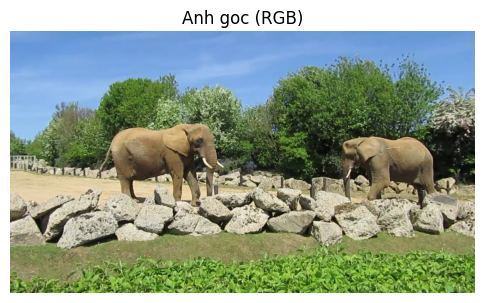

In [2]:
def read_image(image_path: str) -> np.ndarray:
    """Doc anh tu file, tra ve numpy RGB uint8."""
    img = Image.open(str(image_path)).convert('RGB')
    return np.array(img, dtype=np.uint8)

# --- Thu ---
img_rgb = read_image(sample_path)
print(f'Shape: {img_rgb.shape}, dtype: {img_rgb.dtype}')
plt.figure(figsize=(6,4))
plt.imshow(img_rgb)
plt.title('Anh goc (RGB)')
plt.axis('off')
plt.show()

## *II. Resize — Bilinear Interpolation *

### **Lý thuyết**

Khi resize, mỗi pixel `(x', y')` trong ảnh mới sẽ ánh xạ về vị trí `(x, y)` trong ảnh gốc.  
Do `(x, y)` thường là **số thực**, ta không thể lấy trực tiếp pixel mà phải **nội suy từ 4 pixel lân cận**.

Ta xác định:

- `(x0, y0) = (⌊x⌋, ⌊y⌋)` (pixel trên trái)
- `(x1, y1) = (x0 + 1, y0 + 1)`

4 pixel xung quanh:

    P₀₀ = P(x0, y0)    (trên trái)
    P₁₀ = P(x1, y0)    (trên phải)
    P₀₁ = P(x0, y1)    (dưới trái)
    P₁₁ = P(x1, y1)    (dưới phải)

Hình dung:

        P₀₀ -------- P₁₀
         |            |
         |   (x, y)   |
         |            |
        P₀₁ -------- P₁₁

---

### **Tính khoảng lệch**

    dx = x − ⌊x⌋   (độ lệch theo trục X)
    dy = y − ⌊y⌋   (độ lệch theo trục Y)

Trong đó:
- `⌊x⌋` là floor(x): làm tròn xuống số nguyên gần nhất  
- `dx, dy ∈ [0, 1)`

---

### **Công thức nội suy**

    pixel = (1 − dx)(1 − dy) · P₀₀  
          + dx(1 − dy)     · P₁₀  
          + (1 − dx)dy     · P₀₁  
          + dx·dy          · P₁₁

---

### **Ý nghĩa**

Đây là phép **trung bình có trọng số của 4 pixel lân cận**:

- Pixel nào **gần (x, y)** hơn → trọng số lớn hơn  
- Pixel xa hơn → ảnh hưởng ít hơn  

=> Giúp ảnh resize **mượt hơn, không bị răng cưa** so với nearest neighbor.

---

### **Ví dụ**

Giả sử:

    x = 2.3 → dx = 0.3  
    y = 4.7 → dy = 0.7  

→ Điểm `(x, y)` nằm gần phía **dưới** hơn → các pixel phía dưới (P₀₁, P₁₁) ảnh hưởng nhiều hơn.

Dang resize (bilinear)... mat khoang 1-2 phut
Sau resize: (224, 224, 3)


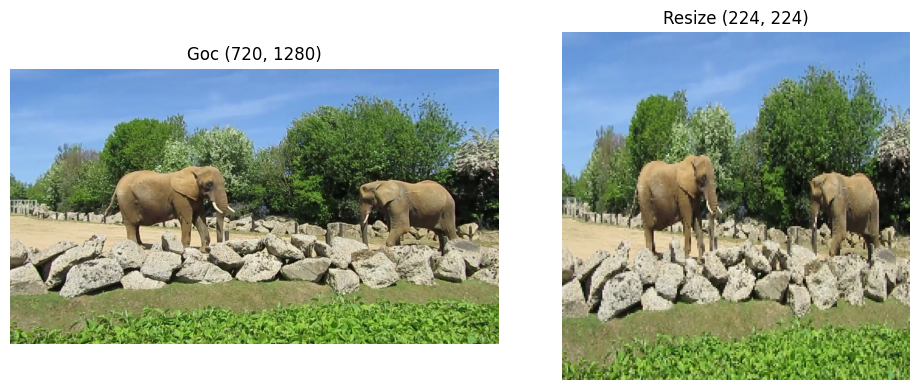

In [4]:
def resize_bilinear(image, new_width, new_height):
    old_h, old_w = image.shape[0], image.shape[1]
    # nếu là ảnh màu rgb thì channels = 3, ảnh xám thì = 1
    channels = image.shape[2] if image.ndim == 3 else 1
    # đưa các giá trị về float để dễ tính toán thay vì uint8(0-255)
    img_f = image.astype(np.float64)
    # tạo ảnh kq
    result = np.zeros((new_height, new_width, channels), dtype=np.float64)

    x_ratio = old_w / new_width
    y_ratio = old_h / new_height

    for row in range(new_height):
        for col in range(new_width):
            # Toa do tuong ung trong anh goc (center-align)
            x = (col + 0.5) * x_ratio - 0.5
            y = (row + 0.5) * y_ratio - 0.5

            # 4 pixel lan can
            x0 = max(int(math.floor(x)), 0)
            y0 = max(int(math.floor(y)), 0)
            x1 = min(x0 + 1, old_w - 1)
            y1 = min(y0 + 1, old_h - 1)

            # Trong so
            dx = max(x - math.floor(x), 0.0)
            dy = max(y - math.floor(y), 0.0)

            # Noi suy
            result[row, col] = ((1-dx)*(1-dy) * img_f[y0, x0]
                              + dx*(1-dy)     * img_f[y0, x1]
                              + (1-dx)*dy     * img_f[y1, x0]
                              + dx*dy         * img_f[y1, x1])

    return np.clip(result, 0, 255).astype(np.uint8)

# --- Thu ---
print('Dang resize (bilinear)... mat khoang 1-2 phut')
img_resized = resize_bilinear(img_rgb, TARGET_SIZE[0], TARGET_SIZE[1])
print(f'Sau resize: {img_resized.shape}')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(img_rgb); axes[0].set_title(f'Goc {img_rgb.shape[:2]}')
axes[1].imshow(img_resized); axes[1].set_title(f'Resize {img_resized.shape[:2]}')
for ax in axes: ax.axis('off')
plt.tight_layout(); plt.show()

## **III. Chuyển RGB → HSV (Thủ công)**

### Tại sao dùng HSV thay vì RGB?
- **RGB** trộn lẫn thông tin màu sắc và độ sáng. Cùng một màu đỏ nhưng sáng/tối khác nhau sẽ có RGB rất khác.
- **HSV** tách biệt: H = màu sắc, S = độ đậm, V = độ sáng → Histogram HSV **bền vững** hơn với thay đổi ánh sáng.

### Công thức
1. Chuẩn hóa RGB về `[0, 1]`: `R' = R/255`
2. `Cmax = max(R', G', B')`, `Cmin = min(...)`, `Δ = Cmax - Cmin`
3. **Hue:**
   - `Δ = 0` → `H = 0` (màu xám)
   - `Cmax = R'` → `H = 60 × ((G'-B')/Δ mod 6)`
   - `Cmax = G'` → `H = 60 × ((B'-R')/Δ + 2)`
   - `Cmax = B'` → `H = 60 × ((R'-G')/Δ + 4)`
   - OpenCV chia H cho 2 → `[0, 179]`
4. **Saturation:** `S = Δ/Cmax × 255` (hoặc 0 nếu Cmax=0)
5. **Value:** `V = Cmax × 255`

HSV shape: (224, 224, 3)
  H range: [0, 178]  (0-179)
  S range: [0, 255]  (0-255)
  V range: [7, 255]  (0-255)


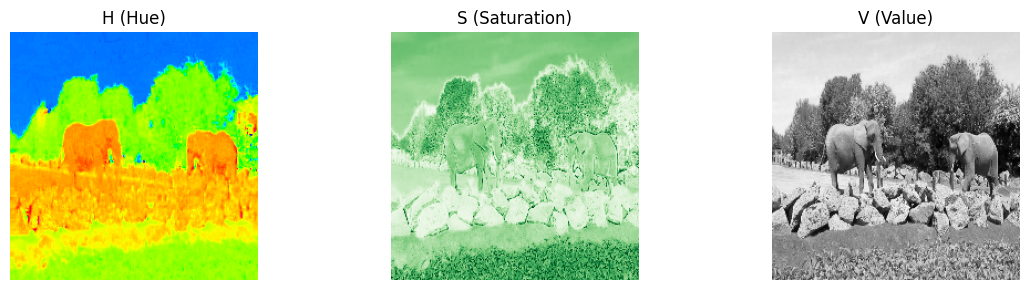

In [5]:
def rgb_to_hsv_manual(image_rgb):
    """
    Chuyen RGB -> HSV thu cong. KHONG dung cv2.cvtColor.
    Output: H [0,179], S [0,255], V [0,255] (chuan OpenCV).
    """
    img = image_rgb.astype(np.float64) / 255.0
    r, g, b = img[:,:,0], img[:,:,1], img[:,:,2]

    c_max = np.maximum(np.maximum(r, g), b)
    c_min = np.minimum(np.minimum(r, g), b)
    delta = c_max - c_min

    # --- Tính Hue ---
    h = np.zeros_like(delta)
    mask = delta > 0
    mr = (c_max == r) & mask
    mg = (c_max == g) & mask
    mb = (c_max == b) & mask

    h[mr] = 60.0 * (((g[mr] - b[mr]) / delta[mr]) % 6.0)
    h[mg] = 60.0 * (((b[mg] - r[mg]) / delta[mg]) + 2.0)
    h[mb] = 60.0 * (((r[mb] - g[mb]) / delta[mb]) + 4.0)
    h[h < 0] += 360.0
    h = h / 2.0  # OpenCV convention: [0, 179]

    # --- Tính Saturation ---
    s = np.zeros_like(delta)
    nz = c_max > 0
    s[nz] = (delta[nz] / c_max[nz]) * 255.0

    # --- Tính Value ---
    v = c_max * 255.0

    hsv = np.stack([h, s, v], axis=-1)
    return np.clip(hsv, 0, 255).astype(np.uint8)

# --- Thu ---
img_hsv = rgb_to_hsv_manual(img_resized)
print(f'HSV shape: {img_hsv.shape}')
print(f'  H range: [{img_hsv[:,:,0].min()}, {img_hsv[:,:,0].max()}]  (0-179)')
print(f'  S range: [{img_hsv[:,:,1].min()}, {img_hsv[:,:,1].max()}]  (0-255)')
print(f'  V range: [{img_hsv[:,:,2].min()}, {img_hsv[:,:,2].max()}]  (0-255)')

fig, axes = plt.subplots(1, 3, figsize=(12, 3))
titles = ['H (Hue)', 'S (Saturation)', 'V (Value)']
cmaps  = ['hsv', 'Greens', 'gray']
for i in range(3):
    axes[i].imshow(img_hsv[:,:,i], cmap=cmaps[i])
    axes[i].set_title(titles[i]); axes[i].axis('off')
plt.tight_layout(); plt.show()

## **IV. Tính Histogram 3D (Thủ công)**

### Histogram là gì?
Bảng đếm tần suất: mỗi pixel được phân loại vào một **bin** (ngăn) dựa trên giá trị, rồi đếm số pixel trong mỗi bin.

### Histogram 3D
Với 3 kênh (H, S, V) và số bin `(bH, bS, bV)`, ta có mảng 3 chiều:
- `hist[i][j][k]` = số pixel có H thuộc bin i, S thuộc bin j, V thuộc bin k

### Cách tính bin index
```
bin_width = (max - min) / n_bins
index = floor((value - min) / bin_width)
index = clamp(index, 0, n_bins - 1)
```

### Tại sao Histogram 3D thay vì 3 Histogram 1D?
Histogram 3D giữ được **tương quan** giữa các kênh. Ví dụ: pixel "đỏ + sáng" và "đỏ + tối" sẽ ở bin khác nhau trong hist 3D, nhưng bị gộp chung nếu chỉ dùng hist 1D cho kênh H.

Histogram: [3.000e+01 2.200e+01 2.100e+01 1.400e+01 1.370e+02 2.900e+01 0.000e+00
 0.000e+00 2.500e+01 0.000e+00 0.000e+00 0.000e+00 4.000e+00 0.000e+00
 0.000e+00 0.000e+00 5.100e+01 2.660e+02 9.660e+02 2.225e+03 5.190e+02
 1.360e+03 1.676e+03 1.393e+03 2.050e+02 1.790e+02 4.700e+01 0.000e+00
 7.900e+01 7.000e+00 0.000e+00 0.000e+00 1.070e+02 3.260e+02 1.812e+03
 2.553e+03 3.080e+02 9.740e+02 3.525e+03 9.700e+01 1.570e+02 5.900e+01
 2.000e+00 0.000e+00 5.800e+01 0.000e+00 0.000e+00 0.000e+00 2.260e+02
 2.180e+02 2.840e+02 7.800e+01 5.180e+02 1.473e+03 2.432e+03 3.860e+02
 2.740e+02 1.702e+03 2.875e+03 4.170e+02 1.280e+02 9.770e+02 2.080e+02
 0.000e+00 2.120e+02 1.890e+02 2.160e+02 3.700e+01 9.300e+02 1.462e+03
 5.590e+02 1.700e+01 6.310e+02 1.165e+03 1.560e+02 2.000e+00 2.310e+02
 3.580e+02 3.000e+00 0.000e+00 8.800e+01 9.000e+01 1.220e+02 5.000e+00
 8.600e+01 9.100e+01 1.000e+01 0.000e+00 2.000e+00 2.000e+00 0.000e+00
 0.000e+00 4.000e+00 0.000e+00 0.000e+00 0.000e+00 3.000e+01 6.100

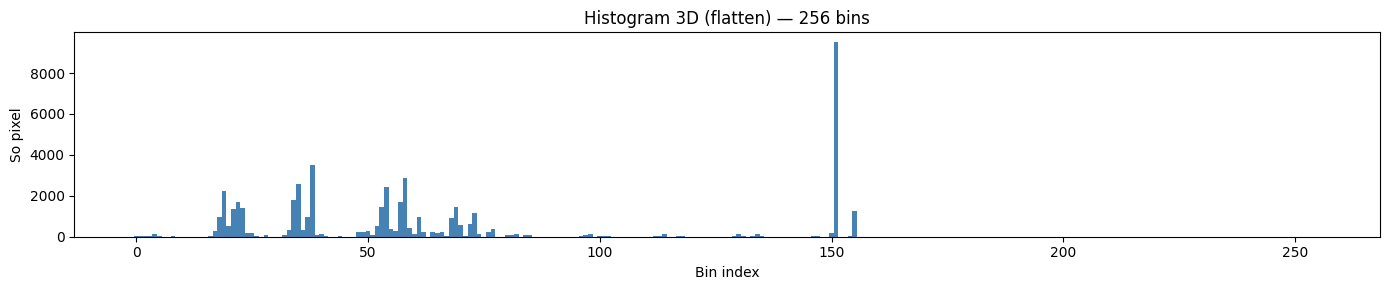

In [8]:
def compute_hsv_histogram(image_hsv, bins=HIST_BINS, ranges=None):
    if ranges is None: ranges = HIST_RANGES
    bh, bs, bv = bins

    h_ch = image_hsv[:,:,0].astype(np.float64) # ma trận H
    s_ch = image_hsv[:,:,1].astype(np.float64) # ma trận S
    v_ch = image_hsv[:,:,2].astype(np.float64) # ma trận V
    
    hist = np.zeros((bh, bs, bv), dtype=np.float64)
    height, width = image_hsv.shape[:2]

    for row in range(height):
        for col in range(width):
            h = h_ch[row, col]
            s = s_ch[row, col]
            v = v_ch[row, col]
            
            
           # Tinh bin index 
            i = int(h / 180 * bh)
            j = int(s / 256 * bs)
            k = int(v / 256 * bv)

            # Tranh out of range
            i = min(i, bh - 1)
            j = min(j, bs - 1)
            k = min(k, bv - 1)

            hist[i, j, k] += 1

    return hist.flatten()

# --- Thu ---
hist = compute_hsv_histogram(img_hsv)
total_pixels = TARGET_SIZE[0] * TARGET_SIZE[1]
print(f'Histogram: {hist}')
print(f'Tong histogram:  {hist.sum():.0f}  (phai = {total_pixels})')
print(f'Min: {hist.min():.0f}, Max: {hist.max():.0f}')

plt.figure(figsize=(14, 3))
plt.bar(range(len(hist)), hist, width=1.0, color='steelblue')
plt.title(f'Histogram 3D (flatten) — {len(hist)} bins')
plt.xlabel('Bin index'); plt.ylabel('So pixel')
plt.tight_layout(); plt.show()

## **V. Chuẩn hóa L2 (Thủ công)**

### Công thức
```
||v||₂ = √(v₁² + v₂² + ... + vₙ²)
v_norm = v / ||v||₂
```

### Tại sao cần chuẩn hóa?
- Loại bỏ ảnh hưởng của **tổng số pixel** (ảnh to/nhỏ có tổng histogram khác nhau, nhưng **tỷ lệ** tương tự).
- Sau chuẩn hóa: `||v|| = 1` → cosine similarity = dot product (nhanh hơn).

[0.00240897 0.00176658 0.00168628 0.00112418 0.01100095 0.00232867
 0.         0.         0.00200747 0.         0.         0.
 0.0003212  0.         0.         0.         0.00409524 0.02135951
 0.07756874 0.17866505 0.04167513 0.1092065  0.13458095 0.11185637
 0.01646127 0.0143735  0.00377405 0.         0.00634361 0.00056209
 0.         0.         0.00859198 0.02617744 0.1455016  0.20500309
 0.02473206 0.07821113 0.28305362 0.00778899 0.01260693 0.00473764
 0.0001606  0.         0.00465734 0.         0.         0.
 0.01814755 0.01750516 0.02280489 0.00626331 0.04159483 0.11828028
 0.19528692 0.03099537 0.0220019  0.13666873 0.23085933 0.03348464
 0.01027826 0.07845202 0.01670217 0.         0.01702337 0.01517649
 0.01734456 0.00297106 0.07467798 0.11739699 0.04488708 0.00136508
 0.05066861 0.09354822 0.01252663 0.0001606  0.01854905 0.02874701
 0.0002409  0.         0.0070663  0.0072269  0.00979647 0.00040149
 0.00690571 0.0073072  0.00080299 0.         0.0001606  0.0001606
 0.         

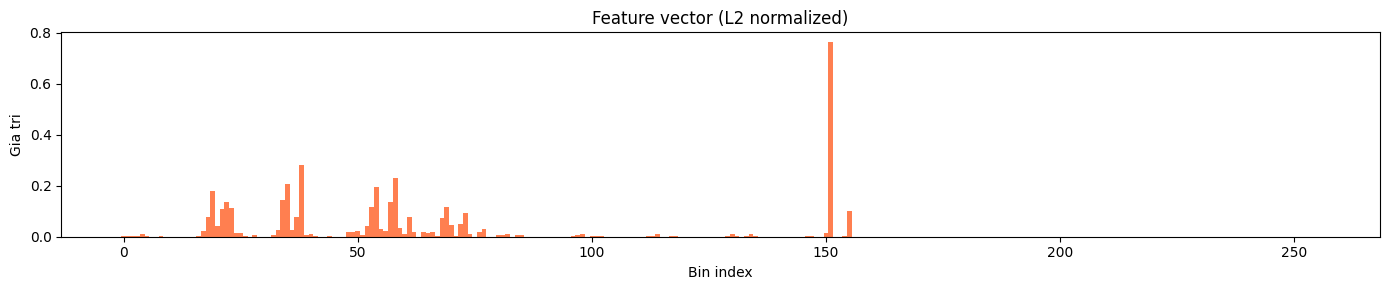

In [10]:
def normalize_l2(vector):
    sum_sq = 0.0
    for val in vector:
        sum_sq += val * val
    norm = math.sqrt(sum_sq)
    if norm == 0:
        return vector
    return vector / norm

# --- Thu ---
vec = normalize_l2(hist)
norm_check = math.sqrt(sum(v*v for v in vec))
np.set_printoptions(suppress=True)
print(vec)
print(f'Vector shape:  {vec.shape}')
print(f'L2 norm:       {norm_check:.6f}  (phai = 1.0) ✓')
print(f'Min: {vec.min():.6f}, Max: {vec.max():.6f}')

plt.figure(figsize=(14, 3))
plt.bar(range(len(vec)), vec, width=1.0, color='coral')
plt.title('Feature vector (L2 normalized)')
plt.xlabel('Bin index'); plt.ylabel('Gia tri')
plt.tight_layout(); plt.show()

## **VI. Cosine Similarity (Thủ công)**

### Công thức
```
cos(v₁, v₂) = (v₁ · v₂) / (||v₁|| × ||v₂||)
```
- `= 1`: giống hoàn toàn
- `= 0`: không liên quan
- `= -1`: đối lập

In [ ]:
def cosine_similarity(v1, v2):
    """Cosine similarity — KHONG dung np.dot."""
    dot = 0.0; n1 = 0.0; n2 = 0.0
    for i in range(len(v1)):
        dot += v1[i] * v2[i]
        n1  += v1[i] * v1[i]
        n2  += v2[i] * v2[i]
    n1 = math.sqrt(n1); n2 = math.sqrt(n2)
    if n1 == 0 or n2 == 0: return 0.0
    return dot / (n1 * n2)

# --- Thu: so sanh vector voi chinh no ---
sim_self = cosine_similarity(vec, vec)
print(f'Cosine(vec, vec) = {sim_self:.6f}  (phai = 1.0) ✓')

## **VII. Pipeline hoàn chỉnh**

Gộp tất cả các bước lại thành 1 hàm duy nhất.

In [ ]:
def extract_histogram_vector(image_path, target_size=TARGET_SIZE, bins=HIST_BINS):
    """
    Pipeline hoan chinh:
      1. Doc anh (Pillow)
      2. Resize (bilinear thu cong)
      3. RGB -> HSV (thu cong)
      4. Histogram 3D (thu cong)
      5. L2 normalize (thu cong)
    """
    img = read_image(image_path)
    resized = resize_bilinear(img, target_size[0], target_size[1])
    hsv = rgb_to_hsv_manual(resized)
    hist = compute_hsv_histogram(hsv, bins)
    return normalize_l2(hist)

print('Pipeline san sang!')

## **VIII. Demo: So sánh 2 ảnh**

In [ ]:
# Lay 2 anh khac nhau
all_images = sorted(KEYFRAME_DIR.rglob('*.jpg'))
print(f'Tim thay {len(all_images)} anh\n')

if len(all_images) >= 2:
    path1, path2 = str(all_images[0]), str(all_images[1])
    print(f'Anh 1: {Path(path1).name}')
    print(f'Anh 2: {Path(path2).name}')
    print('\nDang tinh vector (resize mat ~1-2 phut/anh)...')

    v1 = extract_histogram_vector(path1)
    print('  Anh 1 xong.')
    v2 = extract_histogram_vector(path2)
    print('  Anh 2 xong.')

    sim = cosine_similarity(v1, v2)
    print(f'\nCosine similarity = {sim:.4f}')

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].imshow(read_image(path1)); axes[0].set_title(Path(path1).name)
    axes[1].imshow(read_image(path2)); axes[1].set_title(Path(path2).name)
    for ax in axes: ax.axis('off')
    plt.suptitle(f'Cosine Similarity = {sim:.4f}', fontsize=14, fontweight='bold')
    plt.tight_layout(); plt.show()
else:
    print('Can it nhat 2 anh de so sanh.')

## **Tóm tắt**

| # | Hàm | Thuật toán | Thay thế cho |
|---|------|-----------|-------|
| 1 | `read_image()` | Pillow (I/O) | `cv2.imread()` |
| 2 | `resize_bilinear()` | Bilinear Interpolation | `cv2.resize()` |
| 3 | `rgb_to_hsv_manual()` | Công thức toán học RGB→HSV | `cv2.cvtColor()` |
| 4 | `compute_hsv_histogram()` | Đếm tần suất bin 3D | `cv2.calcHist()` |
| 5 | `normalize_l2()` | `√(Σvᵢ²)` | `np.linalg.norm()` |
| 6 | `cosine_similarity()` | `dot/(‖v₁‖·‖v₂‖)` | `np.dot()` |